In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [ ]:
import os
path = "/content/drive/MyDrive/Bitcoin Project"
print(os.listdir(path))

['.ipynb_checkpoints', 'btc_1d_data_2018_to_2025.csv', 'bitcoin_transactions_confirmed.csv', 'final_merged_dataset.csv', 'monthly_dataset.csv', 'yearly_dataset.csv']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load Bitcoin price dataset
price_df = pd.read_csv('/content/drive/MyDrive/Bitcoin Project/btc_1d_data_2018_to_2025.csv')
# Load transaction dataset
tx_df = pd.read_csv('/content/drive/MyDrive/Bitcoin Project/bitcoin_transactions_confirmed.csv', sep='\t')
# Display first 5 rows
print("PRICE DATASET")
display(price_df.head())

print("\nTRANSACTION DATASET")
display(tx_df.head())

PRICE DATASET


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,114799747.4,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092110,2018-01-02 23:59:59.999000 UTC,279717107.4,177728,11346.326740,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667640,2018-01-03 23:59:59.999000 UTC,236116868.3,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649570,2018-01-04 23:59:59.999000 UTC,312781583.8,170310,12680.812950,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491130,2018-01-05 23:59:59.999000 UTC,369321956.5,192969,13346.622290,2.118299e+08,0



TRANSACTION DATASET


,Unnamed: 0,transactions,input_value,output_value,fee,day,month,year
0,0,7,1.790000e+10,1.790000e+10,0.0,12,1,2009
1,1,3,6.100000e+09,6.100000e+09,0.0,14,1,2009
2,2,15,5.000000e+10,5.000000e+10,0.0,15,1,2009
3,3,4,2.000000e+10,2.000000e+10,0.0,16,1,2009
4,4,3,1.500000e+10,1.500000e+10,0.0,18,1,2009


In [ ]:
# Check dataset shapes
print("PRICE DATASET SHAPE:", price_df.shape)
print("TRANSACTION DATASET SHAPE:", tx_df.shape)
print("\n----------------------------------\n")
# Check column names
print("PRICE DATASET COLUMNS:")
print(price_df.columns)
print("\nTRANSACTION DATASET COLUMNS:")
print(tx_df.columns)
print("\n----------------------------------\n")
# Check missing values
print("MISSING VALUES IN PRICE DATASET:")
print(price_df.isnull().sum())
print("\nMISSING VALUES IN TRANSACTION DATASET:")
print(tx_df.isnull().sum())

PRICE DATASET SHAPE: (2977, 12)
TRANSACTION DATASET SHAPE: (4937, 8)

----------------------------------

PRICE DATASET COLUMNS:
Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')

TRANSACTION DATASET COLUMNS:
Index(['Unnamed: 0', 'transactions', 'input_value', 'output_value', 'fee',
       'day', 'month', 'year'],
      dtype='object')

----------------------------------

MISSING VALUES IN PRICE DATASET:
Open time                       0
Open                            0
High                            0
Low                             0
Close                           0
Volume                          0
Close time                      0
Quote asset volume              0
Number of trades                0
Taker buy base asset volume     0
Taker buy quote asset volume    0
Ignore                          0
dtype:

In [ ]:
print(price_df.columns)

Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')


In [ ]:
# Keep only important columns from price dataset

# Rename columns for easier handling

# Display cleaned dataset
print("CLEANED PRICE DATASET")
display(price_df.head())

CLEANED PRICE DATASET


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000 UTC,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,114799747.4,105595,3961.938946,5.280975e+07,0
1,2018-01-02 00:00:00.000000 UTC,13382.16,15473.49,12890.02,14675.11,20078.092110,2018-01-02 23:59:59.999000 UTC,279717107.4,177728,11346.326740,1.580801e+08,0
2,2018-01-03 00:00:00.000000 UTC,14690.00,15307.56,14150.00,14919.51,15905.667640,2018-01-03 23:59:59.999000 UTC,236116868.3,162787,8994.953566,1.335873e+08,0
3,2018-01-04 00:00:00.000000 UTC,14919.51,15280.00,13918.04,15059.54,21329.649570,2018-01-04 23:59:59.999000 UTC,312781583.8,170310,12680.812950,1.861168e+08,0
4,2018-01-05 00:00:00.000000 UTC,15059.56,17176.24,14600.00,16960.39,23251.491130,2018-01-05 23:59:59.999000 UTC,369321956.5,192969,13346.622290,2.118299e+08,0


In [ ]:
# Create Date column using year, month, day

tx_df['Date'] = pd.to_datetime(tx_df[['year', 'month', 'day']])

# Keep only important columns
tx_df = tx_df[['Date', 'transactions', 'fee']]

# Rename columns
tx_df.columns = ['Date', 'Transactions', 'Transaction_Fee']

# Display cleaned transaction dataset
print("CLEANED TRANSACTION DATASET")
display(tx_df.head())

CLEANED TRANSACTION DATASET


,Date,Transactions,Transaction_Fee
0,2009-01-12,7,0.0
1,2009-01-14,3,0.0
2,2009-01-15,15,0.0
3,2009-01-16,4,0.0
4,2009-01-18,3,0.0


In [ ]:
# Convert Date columns to datetime format

price_df['Open time'] = pd.to_datetime(
    price_df['Open time']
).dt.date

tx_df['Date'] = pd.to_datetime(
    tx_df['Date']
).dt.date

# Check output
print(price_df.head())

print(tx_df.head())

    Open time      Open      High       Low     Close        Volume  \
0  2018-01-01  13715.65  13818.55  12750.00  13380.00   8609.915844   
1  2018-01-02  13382.16  15473.49  12890.02  14675.11  20078.092110   
2  2018-01-03  14690.00  15307.56  14150.00  14919.51  15905.667640   
3  2018-01-04  14919.51  15280.00  13918.04  15059.54  21329.649570   
4  2018-01-05  15059.56  17176.24  14600.00  16960.39  23251.491130   

                       Close time  Quote asset volume  Number of trades  \
0  2018-01-01 23:59:59.999000 UTC         114799747.4            105595   
1  2018-01-02 23:59:59.999000 UTC         279717107.4            177728   
2  2018-01-03 23:59:59.999000 UTC         236116868.3            162787   
3  2018-01-04 23:59:59.999000 UTC         312781583.8            170310   
4  2018-01-05 23:59:59.999000 UTC         369321956.5            192969   

   Taker buy base asset volume  Taker buy quote asset volume  Ignore  
0                  3961.938946                  5.2

In [ ]:
# Merge datasets using Date column

merged_df = pd.merge(price_df, tx_df, left_on='Open time', right_on='Date', how='inner')
# Display merged dataset
print("MERGED DATASET")
display(merged_df.head())

# Check shape
print("Merged Dataset Shape:", merged_df.shape)

MERGED DATASET


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore,Date,Transactions,Transaction_Fee
0,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,114799747.4,105595,3961.938946,5.280975e+07,0,2018-01-01,846239,4.060362e+12
1,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092110,2018-01-02 23:59:59.999000 UTC,279717107.4,177728,11346.326740,1.580801e+08,0,2018-01-02,877875,3.920218e+12
2,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667640,2018-01-03 23:59:59.999000 UTC,236116868.3,162787,8994.953566,1.335873e+08,0,2018-01-03,771447,3.542215e+12
3,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649570,2018-01-04 23:59:59.999000 UTC,312781583.8,170310,12680.812950,1.861168e+08,0,2018-01-04,805066,2.472712e+12
4,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491130,2018-01-05 23:59:59.999000 UTC,369321956.5,192969,13346.622290,2.118299e+08,0,2018-01-05,685154,2.418848e+12


Merged Dataset Shape: (1912, 15)


In [ ]:
# Check starting and ending dates

print("Starting Date:", merged_df['Date'].min())
print("Ending Date:", merged_df['Date'].max())

Starting Date: 2018-01-01
Ending Date: 2023-03-27


In [ ]:
# Save cleaned merged dataset

merged_df.to_csv('/content/drive/MyDrive/Bitcoin Project/final_merged_dataset.csv', index=False)

print("Final merged dataset saved successfully!")

Final merged dataset saved successfully!


In [ ]:
# Convert Date column to datetime format

merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Set Date as index
merged_df.set_index('Date', inplace=True)

# Display dataset
display(merged_df.head())

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore,Transactions,Transaction_Fee
Date,,,,,,,,,,,,,,
2018-01-01,2018-01-01,13715.65,13818.55,12750.00,13380.00,8609.915844,2018-01-01 23:59:59.999000 UTC,114799747.4,105595,3961.938946,5.280975e+07,0,846239,4.060362e+12
2018-01-02,2018-01-02,13382.16,15473.49,12890.02,14675.11,20078.092110,2018-01-02 23:59:59.999000 UTC,279717107.4,177728,11346.326740,1.580801e+08,0,877875,3.920218e+12
2018-01-03,2018-01-03,14690.00,15307.56,14150.00,14919.51,15905.667640,2018-01-03 23:59:59.999000 UTC,236116868.3,162787,8994.953566,1.335873e+08,0,771447,3.542215e+12
2018-01-04,2018-01-04,14919.51,15280.00,13918.04,15059.54,21329.649570,2018-01-04 23:59:59.999000 UTC,312781583.8,170310,12680.812950,1.861168e+08,0,805066,2.472712e+12
2018-01-05,2018-01-05,15059.56,17176.24,14600.00,16960.39,23251.491130,2018-01-05 23:59:59.999000 UTC,369321956.5,192969,13346.622290,2.118299e+08,0,685154,2.418848e+12


In [ ]:
# Create monthly dataset

monthly_df = merged_df.copy()

# Convert Open time to proper datetime
monthly_df['Open time'] = pd.to_datetime(
    monthly_df['Open time']
)

# Set datetime index and calculate monthly averages
monthly_df = monthly_df.set_index('Open time') \
                       .select_dtypes(include=['number']) \
                       .resample('M') \
                       .mean()

# Display monthly dataset
print("MONTHLY DATASET")

display(monthly_df.head())

# Check shape
print("Monthly Dataset Shape:", monthly_df.shape)

MONTHLY DATASET


/tmp/ipykernel_841/3751838100.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M') \


,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore,Transactions,Transaction_Fee
Open time,,,,,,,,,,,,
2018-01-31,13003.754516,13582.501613,11903.526774,12890.369032,26344.373049,3.219254e+08,232741.193548,13093.565326,1.612510e+08,0.0,830317.709677,2.587226e+12
2018-02-28,9371.613929,9862.317857,8826.998571,9373.327500,44426.459119,4.134500e+08,417313.714286,21617.738058,2.013312e+08,0.0,782828.928571,5.341881e+11
2018-03-31,9095.151935,9371.560968,8624.362903,8985.636774,39849.235937,3.480463e+08,297967.806452,19380.935828,1.693220e+08,0.0,611357.064516,1.622926e+11
2018-04-30,7944.672333,8224.184333,7733.024000,8022.323333,37032.133854,2.987803e+08,247368.533333,18766.355566,1.515315e+08,0.0,517395.100000,1.622045e+11
2018-05-31,8483.459677,8651.490968,8222.248065,8425.817097,29499.237997,2.489372e+08,239798.064516,15031.095044,1.266960e+08,0.0,527671.709677,1.726410e+11


Monthly Dataset Shape: (63, 12)


In [ ]:
# Create yearly dataset

yearly_df = merged_df.copy()

# Convert Open time to proper datetime
yearly_df['Open time'] = pd.to_datetime(
    yearly_df['Open time']
)

# Set datetime index and calculate yearly averages
yearly_df = yearly_df.set_index('Open time') \
                     .select_dtypes(include=['number']) \
                     .resample('Y') \
                     .mean()

# Display yearly dataset
print("YEARLY DATASET")

display(yearly_df.head())

# Check shape
print("Yearly Dataset Shape:", yearly_df.shape)

YEARLY DATASET


/tmp/ipykernel_841/3338497249.py:13: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  .resample('Y') \


,Open,High,Low,Close,Volume,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore,Transactions,Transaction_Fee
Open time,,,,,,,,,,,,
2018-12-31,7565.722712,7789.655616,7261.299781,7538.113945,36456.095432,2.623529e+08,2.393150e+05,18760.053961,1.345425e+08,0.0,613850.950685,3.749799e+11
2019-12-31,7354.844685,7547.611808,7152.498493,7364.363205,41999.968609,3.326979e+08,3.585238e+05,21464.109207,1.694020e+08,0.0,710625.380822,1.873257e+11
2020-12-31,11051.096148,11330.868907,10782.702240,11110.548497,70310.568477,7.827410e+08,8.587664e+05,34259.875076,3.820804e+08,0.0,796607.879781,3.264484e+11
2021-12-31,47352.319562,48806.641726,45674.194219,47400.003041,69924.032872,3.162873e+09,1.838111e+06,34412.108268,1.557403e+09,0.0,824692.736986,4.383755e+11
2022-12-31,28266.515041,28896.238192,27520.177699,28185.217890,146441.630313,3.285960e+09,3.289024e+06,72768.444702,1.631081e+09,0.0,822009.345205,8.859648e+10


Yearly Dataset Shape: (6, 12)


In [ ]:
# Save monthly dataset
monthly_df.to_csv('/content/drive/MyDrive/Bitcoin Project/monthly_dataset.csv')

# Save yearly dataset
yearly_df.to_csv('/content/drive/MyDrive/Bitcoin Project/yearly_dataset.csv')

print("Monthly and Yearly datasets saved successfully!")

Monthly and Yearly datasets saved successfully!


In [ ]:
# Features (inputs)
X = monthly_df[['Volume', 'Transactions', 'Transaction_Fee']]

# Target (output)
y = monthly_df['Close']

# Display
print("FEATURES")
display(X.head())

print("\nTARGET")
display(y.head())

FEATURES


,Volume,Transactions,Transaction_Fee
Open time,,,
2018-01-31,26344.373049,830317.709677,2.587226e+12
2018-02-28,44426.459119,782828.928571,5.341881e+11
2018-03-31,39849.235937,611357.064516,1.622926e+11
2018-04-30,37032.133854,517395.100000,1.622045e+11
2018-05-31,29499.237997,527671.709677,1.726410e+11



TARGET


,Close
Open time,
2018-01-31,12890.369032
2018-02-28,9373.327500
2018-03-31,8985.636774
2018-04-30,8022.323333
2018-05-31,8425.817097


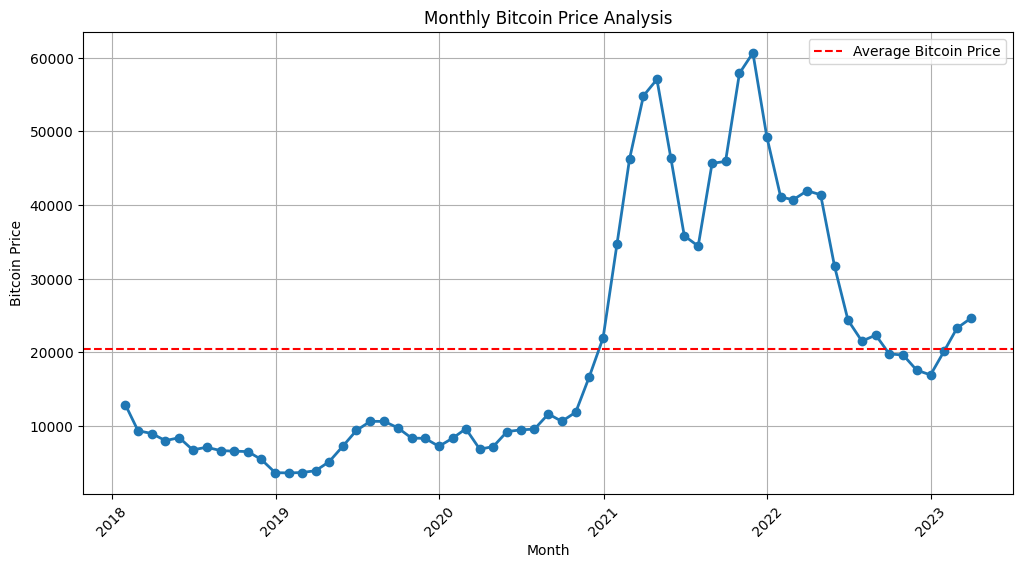

In [ ]:
# Monthly Bitcoin Price Analysis

plt.figure(figsize=(12,6))

plt.plot(
    monthly_df.index,
    monthly_df['Close'],
    marker='o',
    linewidth=2
)

# Average monthly price line
average_price = monthly_df['Close'].mean()

plt.axhline(
    y=average_price,
    color='red',
    linestyle='--',
    label='Average Bitcoin Price'
)

# Title and labels
plt.title('Monthly Bitcoin Price Analysis')

plt.xlabel('Month')
plt.ylabel('Bitcoin Price')

# Rotate dates
plt.xticks(rotation=45)

# Legend
plt.legend()

# Grid
plt.grid(True)

# Show graph
plt.show()

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50, 3)
X_test shape: (13, 3)
y_train shape: (50,)
y_test shape: (13,)


In [ ]:
# Create Linear Regression model

lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
# Predict using Linear Regression model

y_pred = lr_model.predict(X_test)

# Display predictions
print("PREDICTED VALUES")
print(y_pred[:5])

PREDICTED VALUES
[20570.25351233 21254.98948463 26414.08045675 20237.63072497
  2635.91295349]


In [ ]:
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Display results
print("LINEAR REGRESSION EVALUATION")

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

LINEAR REGRESSION EVALUATION
MAE : 7538.377072318813
RMSE: 10817.930754489416
MAPE: 61.38539481651958


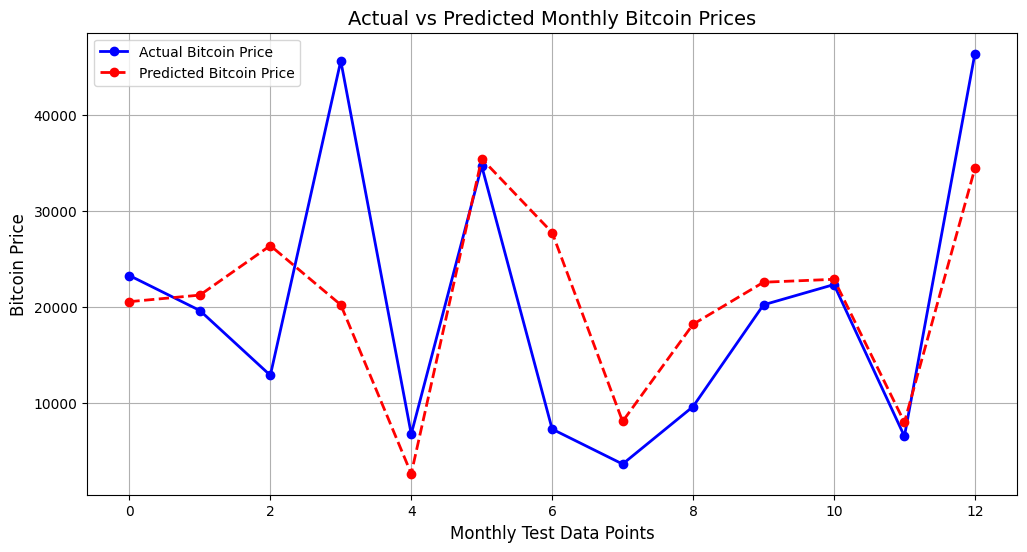

In [ ]:
#  Actual vs Predicted Graph

plt.figure(figsize=(12,6))

# Plot Actual Values
plt.plot(
    y_test.values,
    color='blue',
    marker='o',
    linewidth=2,
    label='Actual Bitcoin Price'
)

# Plot Predicted Values
plt.plot(
    y_pred,
    color='red',
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Predicted Bitcoin Price'
)

# Title and labels
plt.title('Actual vs Predicted Monthly Bitcoin Prices', fontsize=14)

plt.xlabel('Monthly Test Data Points', fontsize=12)
plt.ylabel('Bitcoin Price', fontsize=12)

# Legend
plt.legend()

# Grid
plt.grid(True)

# Show graph
plt.show()

In [ ]:
# Create Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Predict using Random Forest model

rf_pred = rf_model.predict(X_test)

# Display predictions
print("RANDOM FOREST PREDICTIONS")
print(rf_pred[:5])

RANDOM FOREST PREDICTIONS
[21662.39338419 19464.20537971 44653.50894418 23020.15962538
 12283.87901935]


In [ ]:
# Calculate MAE
rf_mae = mean_absolute_error(y_test, rf_pred)

# Calculate RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# Calculate MAPE
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

# Display results
print("RANDOM FOREST EVALUATION")

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("MAPE:", rf_mape)

RANDOM FOREST EVALUATION
MAE : 8854.160364057727
RMSE: 12820.782898438676
MAPE: 64.32941335739855


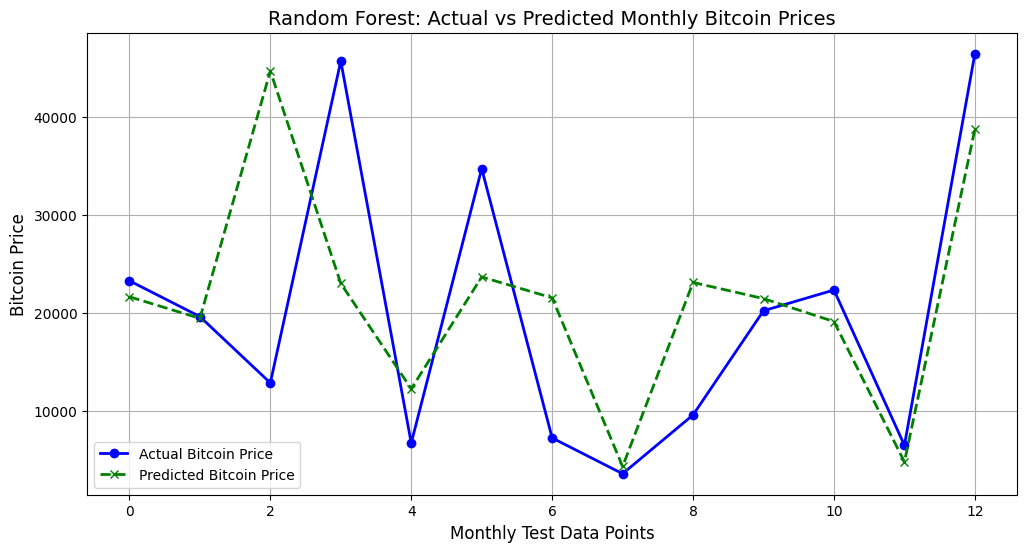

In [ ]:
# Improved Random Forest Graph
plt.figure(figsize=(12,6))
# Actual values
plt.plot(
    y_test.values,
    color='blue',
    marker='o',
    linewidth=2,
    label='Actual Bitcoin Price'
)
# Predicted values
plt.plot(
    rf_pred,
    color='green',
    marker='x',
    linewidth=2,
    linestyle='--',
    label='Predicted Bitcoin Price'
)
plt.title('Random Forest: Actual vs Predicted Monthly Bitcoin Prices', fontsize=14)
plt.xlabel('Monthly Test Data Points', fontsize=12)
plt.ylabel('Bitcoin Price', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Select only Close Price for LSTM

lstm_data = monthly_df[['Close']]

# Display dataset
print("LSTM DATA")
display(lstm_data.head())

LSTM DATA


,Close
Open time,
2018-01-31,12890.369032
2018-02-28,9373.327500
2018-03-31,8985.636774
2018-04-30,8022.323333
2018-05-31,8425.817097


In [ ]:
# Scale data between 0 and 1

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(lstm_data)

# Display scaled values
print("SCALED DATA")
print(scaled_data[:5])

SCALED DATA
[[0.16217418]
 [0.10049246]
 [0.09369316]
 [0.07679861]
 [0.08387507]]


In [ ]:
# Create sequences

X_lstm = []
y_lstm = []

time_step = 3

for i in range(time_step, len(scaled_data)):
    X_lstm.append(scaled_data[i-time_step:i, 0])
    y_lstm.append(scaled_data[i, 0])

# Convert to numpy arrays
X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Display shapes
print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

X_lstm shape: (60, 3)
y_lstm shape: (60,)


In [ ]:
# Reshape data for LSTM

X_lstm = X_lstm.reshape(
    X_lstm.shape[0],
    X_lstm.shape[1],
    1
)

# Display new shape
print("RESHAPED X_lstm SHAPE:", X_lstm.shape)

RESHAPED X_lstm SHAPE: (60, 3, 1)


In [ ]:
# Split data into training and testing sets

train_size = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:train_size]
X_test_lstm = X_lstm[train_size:]

y_train_lstm = y_lstm[:train_size]
y_test_lstm = y_lstm[train_size:]

# Display shapes
print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)

print("y_train_lstm shape:", y_train_lstm.shape)
print("y_test_lstm shape:", y_test_lstm.shape)

X_train_lstm shape: (48, 3, 1)
X_test_lstm shape: (12, 3, 1)
y_train_lstm shape: (48,)
y_test_lstm shape: (12,)


In [ ]:
# Build LSTM model
lstm_model = Sequential()
# First LSTM layer
lstm_model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train_lstm.shape[1], 1)
    )
)
# Dropout layer
lstm_model.add(Dropout(0.2))
# Output layer
lstm_model.add(Dense(1))
# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
# Display model summary
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train LSTM model

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=35,
    batch_size=4,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

Epoch 1/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.1571 - val_loss: 0.0744
Epoch 2/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1042 - val_loss: 0.0343
Epoch 3/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0750 - val_loss: 0.0106
Epoch 4/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0477 - val_loss: 0.0070
Epoch 5/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0399 - val_loss: 0.0118
Epoch 6/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0404 - val_loss: 0.0139
Epoch 7/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0325 - val_loss: 0.0106
Epoch 8/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0300 - val_loss: 0.0100
Epoch 9/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0239 - val_loss: 0.0100
Epoch 10/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0278 - val_loss: 0.0121
Epoch 11/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0236 - val_loss: 0.0091
Epoch 12/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0239 - val_l

In [ ]:
# Predict using LSTM model

lstm_pred = lstm_model.predict(X_test_lstm)

# Reverse scaling
lstm_pred = scaler.inverse_transform(lstm_pred)

# Reverse scaling for actual values
y_test_actual = scaler.inverse_transform(
    y_test_lstm.reshape(-1,1)
)

# Display predictions
print("LSTM PREDICTIONS")
print(lstm_pred[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
LSTM PREDICTIONS
[[39819.24 ]
 [39941.367]
 [37474.79 ]
 [32229.111]
 [26064.15 ]]


In [ ]:
# Calculate MAE
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)

# Calculate RMSE
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_pred))

# Calculate MAPE
lstm_mape = np.mean(
    np.abs((y_test_actual - lstm_pred) / y_test_actual)
) * 100

# Display results
print("LSTM EVALUATION")

print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("MAPE:", lstm_mape)

LSTM EVALUATION
MAE : 4902.890145001947
RMSE: 6077.0378389801435
MAPE: 21.31078891081671


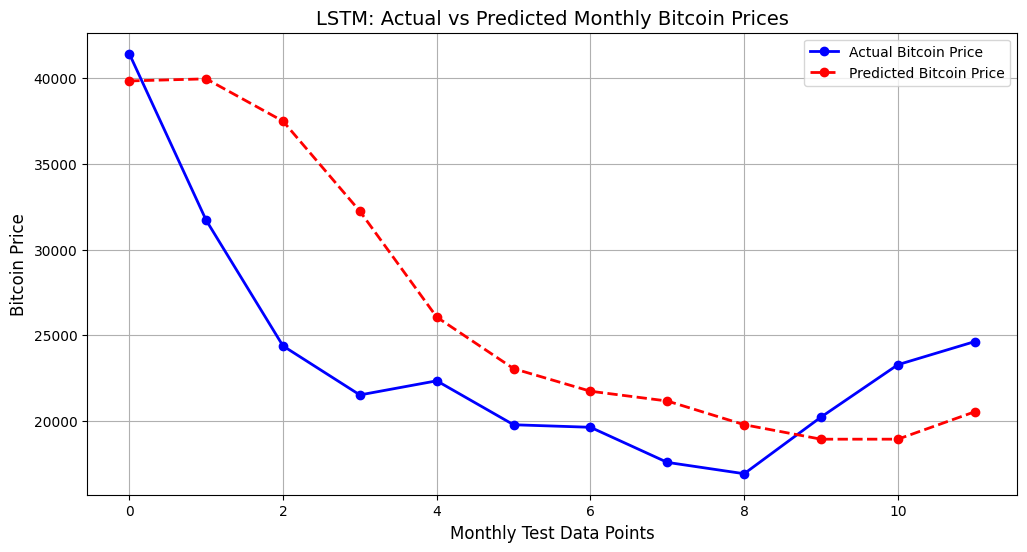

In [ ]:
# Plot Actual vs Predicted values for LSTM

plt.figure(figsize=(12,6))

# Actual values
plt.plot(
    y_test_actual,
    color='blue',
    marker='o',
    linewidth=2,
    label='Actual Bitcoin Price'
)

# Predicted values
plt.plot(
    lstm_pred,
    color='red',
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Predicted Bitcoin Price'
)

# Title and labels
plt.title('LSTM: Actual vs Predicted Monthly Bitcoin Prices', fontsize=14)

plt.xlabel('Monthly Test Data Points', fontsize=12)
plt.ylabel('Bitcoin Price', fontsize=12)

# Legend
plt.legend()

# Grid
plt.grid(True)

# Show graph
plt.show()

In [ ]:
# Create comparison table

comparison_df = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Random Forest',
        'LSTM'
    ],

    'MAE': [
        mae,
        rf_mae,
        lstm_mae
    ],

    'RMSE': [
        rmse,
        rf_rmse,
        lstm_rmse
    ],

    'MAPE': [
        mape,
        rf_mape,
        lstm_mape
    ]
})
# Approximate Accuracy
comparison_df['Approx_Accuracy'] = 100 - comparison_df['MAPE']
# Display comparison table
print("MODEL COMPARISON TABLE")
display(comparison_df)

MODEL COMPARISON TABLE


,Model,MAE,RMSE,MAPE,Approx_Accuracy
0,Linear Regression,7538.377072,10817.930754,61.385395,38.614605
1,Random Forest,8854.160364,12820.782898,64.329413,35.670587
2,LSTM,4902.890145,6077.037839,21.310789,78.689211


In [ ]:
# MAPE Comparison Table

mape_comparison_df = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Random Forest',
        'LSTM'
    ],

    'MAPE (%)': [
        mape,
        rf_mape,
        lstm_mape
    ]

})

print("MODEL MAPE COMPARISON TABLE")

display(mape_comparison_df)

MODEL MAPE COMPARISON TABLE


,Model,MAPE (%)
0,Linear Regression,61.385395
1,Random Forest,64.329413
2,LSTM,21.310789


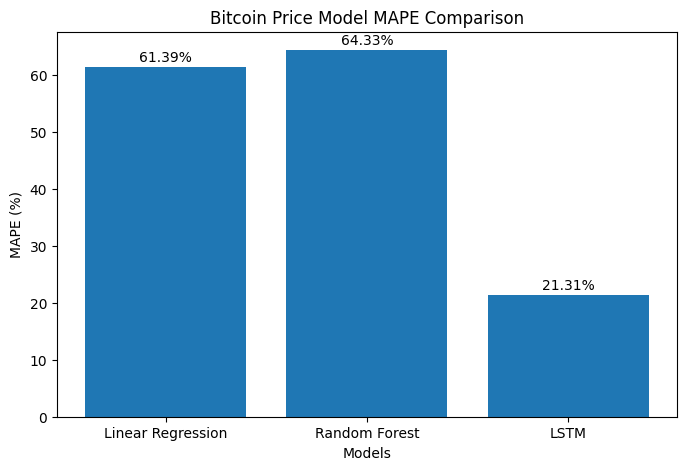

In [ ]:
# Bitcoin Price MAPE Comparison Plot

models = [
    'Linear Regression',
    'Random Forest',
    'LSTM'
]

mape_values = [
    mape,
    rf_mape,
    lstm_mape
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    mape_values
)

# Add MAPE labels on bars
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        f'{yval:.2f}%',
        ha='center'
    )

plt.title(
    'Bitcoin Price Model MAPE Comparison'
)

plt.xlabel('Models')

plt.ylabel('MAPE (%)')

plt.show()

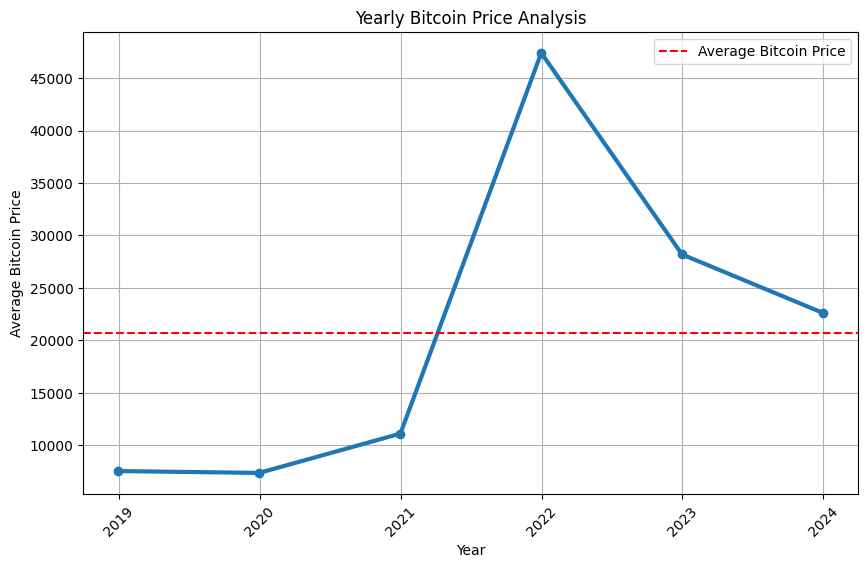

In [ ]:
# Yearly Bitcoin Price Analysis
plt.figure(figsize=(10,6))
plt.plot(
    yearly_df.index,
    yearly_df['Close'],
    marker='o',
    linewidth=3
)
# Average yearly price line
yearly_avg_price = yearly_df['Close'].mean()
plt.axhline(
    y=yearly_avg_price,
    color='red',
    linestyle='--',
    label='Average Bitcoin Price'
)
plt.title('Yearly Bitcoin Price Analysis')
plt.xlabel('Year')
plt.ylabel('Average Bitcoin Price')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Take last sequence from scaled data

last_sequence = scaled_data[-time_step:]

# Reshape for LSTM
future_input = last_sequence.reshape(1, time_step, 1)

# Store future predictions
future_predictions = []

# Predict next 12 months
for i in range(12):

    # Predict next value
    next_pred = lstm_model.predict(future_input)

    # Store prediction
    future_predictions.append(next_pred[0][0])

    # Update sequence
    future_input = np.concatenate(
    (
        future_input[:,1:,:],
        next_pred.reshape(1,1,1)
    ),
    axis=1
)
# Convert predictions back to original scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)
# Display predictions
print("FUTURE BITCOIN PRICE PREDICTIONS")
print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
FUTURE BITCOIN PRICE PREDICTIONS
[[22892.572]
 [23823.75 ]
 [23952.994]
 [23721.527]
 [23997.283]
 [24038.807]
 [24061.967]
 [24168.805]
 [24217.357]
 [24270.82 ]
 [24334.068]
 [24382.867]]


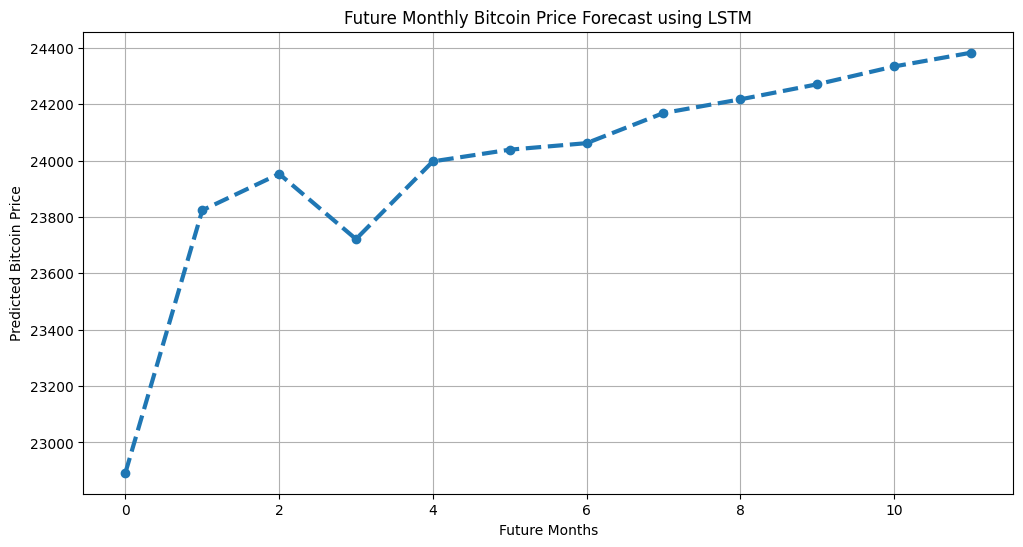

In [ ]:
# Plot future Bitcoin predictions

plt.figure(figsize=(12,6))

plt.plot(
    future_predictions,
    marker='o',
    linewidth=3,
    linestyle='--'
)
plt.title('Future Monthly Bitcoin Price Forecast using LSTM')
plt.xlabel('Future Months')
plt.ylabel('Predicted Bitcoin Price')
plt.grid(True)
plt.show()

In [ ]:
# Select yearly Close prices for LSTM

yearly_lstm_data = yearly_df[['Close']]

# Display dataset
print("YEARLY LSTM DATA")

display(yearly_lstm_data.head())

YEARLY LSTM DATA


,Close
Open time,
2018-12-31,7538.113945
2019-12-31,7364.363205
2020-12-31,11110.548497
2021-12-31,47400.003041
2022-12-31,28185.217890


In [ ]:
# Scale yearly data

from sklearn.preprocessing import MinMaxScaler

yearly_scaler = MinMaxScaler(feature_range=(0,1))

yearly_scaled_data = yearly_scaler.fit_transform(
    yearly_lstm_data
)

print(yearly_scaled_data[:5])

[[0.0043399 ]
 [0.        ]
 [0.09357126]
 [1.        ]
 [0.520058  ]]


In [ ]:
# Create yearly sequences

X_yearly = []
y_yearly = []

time_step = 3

for i in range(time_step, len(yearly_scaled_data)):

    X_yearly.append(
        yearly_scaled_data[i-time_step:i, 0]
    )

    y_yearly.append(
        yearly_scaled_data[i, 0]
    )

# Convert to numpy arrays
X_yearly = np.array(X_yearly)

y_yearly = np.array(y_yearly)

print(X_yearly.shape)

print(y_yearly.shape)

(3, 3)
(3,)


In [ ]:
# Reshape for LSTM

X_yearly = X_yearly.reshape(
    X_yearly.shape[0],
    X_yearly.shape[1],
    1
)

print(X_yearly.shape)

(3, 3, 1)


In [ ]:
# Build yearly LSTM model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Create model
yearly_model = Sequential()

# First LSTM layer
yearly_model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_yearly.shape[1],1)
    )
)

# Second LSTM layer
yearly_model.add(
    LSTM(50)
)

# Output layer
yearly_model.add(
    Dense(1)
)

# Compile model
yearly_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print("YEARLY LSTM MODEL CREATED")

YEARLY LSTM MODEL CREATED


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train yearly LSTM model

yearly_model.fit(
    X_yearly,
    y_yearly,
    epochs=20,
    batch_size=1,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.4612
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4256
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3962
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3601
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3196
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2858
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2454
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2113
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1850
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1576
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1438
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1277
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1232
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1191
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1176
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━━━

In [ ]:
# Predict future yearly Bitcoin prices

future_yearly_predictions = []

yearly_input = yearly_scaled_data[-time_step:]

for i in range(5):

    yearly_input_reshaped = yearly_input.reshape(
        1,
        time_step,
        1
    )

    next_year_pred = yearly_model.predict(
        yearly_input_reshaped,
        verbose=0
    )

    future_yearly_predictions.append(
        next_year_pred[0][0]
    )

    yearly_input = np.append(
        yearly_input[1:],
        next_year_pred,
        axis=0
    )

In [ ]:
# Reverse scaling

future_yearly_predictions = yearly_scaler.inverse_transform(
    np.array(future_yearly_predictions).reshape(-1,1)
)

print("FUTURE YEARLY BITCOIN PRICE PREDICTIONS")

print(future_yearly_predictions)

FUTURE YEARLY BITCOIN PRICE PREDICTIONS
[[34636.81 ]
 [33278.13 ]
 [33432.293]
 [34237.1  ]
 [34167.383]]


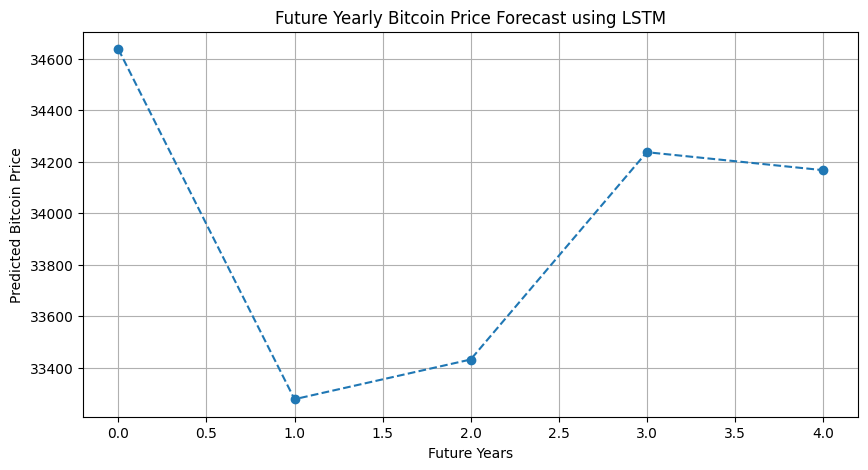

In [ ]:
# Plot yearly forecast graph

plt.figure(figsize=(10,5))

plt.plot(
    future_yearly_predictions,
    marker='o',
    linestyle='--'
)

plt.title(
    "Future Yearly Bitcoin Price Forecast using LSTM"
)

plt.xlabel("Future Years")

plt.ylabel("Predicted Bitcoin Price")

plt.grid(True)

plt.show()

In [ ]:
# Features (inputs)

X_fee = monthly_df[['Volume', 'Transactions', ]]

# Target (output)

y_fee = monthly_df['Transaction_Fee']

# Display
print("FEATURES")
display(X_fee.head())

print("\nTARGET")
display(y_fee.head())

FEATURES


,Volume,Transactions
Open time,,
2018-01-31,26344.373049,830317.709677
2018-02-28,44426.459119,782828.928571
2018-03-31,39849.235937,611357.064516
2018-04-30,37032.133854,517395.100000
2018-05-31,29499.237997,527671.709677



TARGET


,Transaction_Fee
Open time,
2018-01-31,2.587226e+12
2018-02-28,5.341881e+11
2018-03-31,1.622926e+11
2018-04-30,1.622045e+11
2018-05-31,1.726410e+11


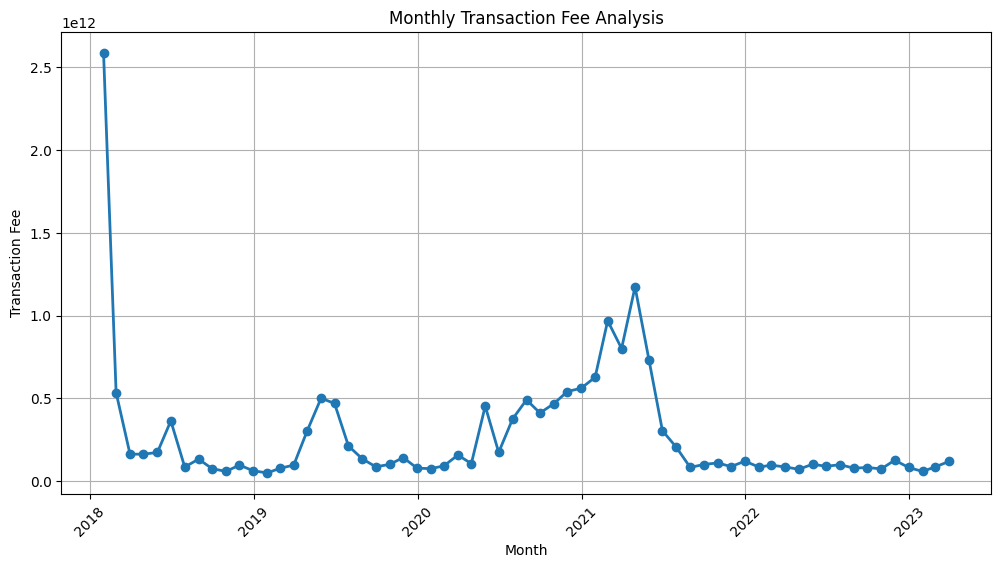

In [ ]:
# Monthly Transaction Fee Analysis
plt.figure(figsize=(12,6))
plt.plot(
    monthly_df.index,
    monthly_df['Transaction_Fee'],
    marker='o',
    linewidth=2
)
plt.title('Monthly Transaction Fee Analysis')
plt.xlabel('Month')
plt.ylabel('Transaction Fee')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# Remove extreme transaction fee outliers

monthly_df = monthly_df[
    monthly_df['Transaction_Fee']
    < monthly_df['Transaction_Fee'].quantile(0.95)
]

print("OUTLIERS REMOVED SUCCESSFULLY")

print("Updated Dataset Shape:")

print(monthly_df.shape)

OUTLIERS REMOVED SUCCESSFULLY
Updated Dataset Shape:
(59, 12)


In [ ]:
# Split data into training and testing sets

X_train_fee, X_test_fee, y_train_fee, y_test_fee = train_test_split(
    X_fee,
    y_fee,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("X_train_fee shape:", X_train_fee.shape)
print("X_test_fee shape:", X_test_fee.shape)

print("y_train_fee shape:", y_train_fee.shape)
print("y_test_fee shape:", y_test_fee.shape)

X_train_fee shape: (50, 2)
X_test_fee shape: (13, 2)
y_train_fee shape: (50,)
y_test_fee shape: (13,)


In [ ]:
# Create Linear Regression model

lr_fee_model = LinearRegression()

# Train model
lr_fee_model.fit(X_train_fee, y_train_fee)

print("Linear Regression model for Transaction Fee trained successfully!")

Linear Regression model for Transaction Fee trained successfully!


In [ ]:
# Predict transaction fees

y_pred_fee = lr_fee_model.predict(X_test_fee)

# Display predictions
print("PREDICTED TRANSACTION FEES")

print(y_pred_fee[:5])

PREDICTED TRANSACTION FEES
[1.59545214e+11 1.89445329e+11 3.83014505e+11 2.37080287e+11
 2.38306710e+10]


In [ ]:
# Linear Regression Transaction Fee Evaluation

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# MAE
fee_mae = mean_absolute_error(
    y_test_fee,
    y_pred_fee
)

# RMSE
fee_rmse = np.sqrt(
    mean_squared_error(
        y_test_fee,
        y_pred_fee
    )
)

# MAPE
fee_mape = np.mean(
    np.abs(
        (y_test_fee - y_pred_fee)
        / y_test_fee
    )
) * 100

# Display results
print("LINEAR REGRESSION TRANSACTION FEE EVALUATION")

print("MAE :", fee_mae)

print("RMSE:", fee_rmse)

print("MAPE:", round(fee_mape,2))

LINEAR REGRESSION TRANSACTION FEE EVALUATION
MAE : 311197296039.4358
RMSE: 634997770332.6649
MAPE: 109.59


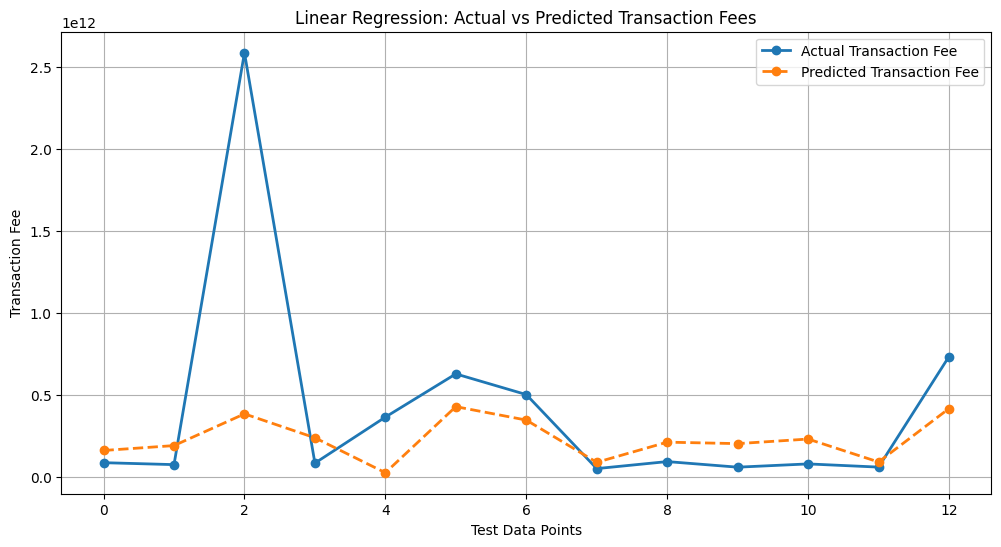

In [ ]:
# Plot Actual vs Predicted Transaction Fees
plt.figure(figsize=(12,6))
# Actual values
plt.plot(
    y_test_fee.values,
    marker='o',
    linewidth=2,
    label='Actual Transaction Fee'
)
# Predicted values
plt.plot(
    y_pred_fee,
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Predicted Transaction Fee'
)
plt.title('Linear Regression: Actual vs Predicted Transaction Fees')
plt.xlabel('Test Data Points')
plt.ylabel('Transaction Fee')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Create Random Forest model

rf_fee_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_fee_model.fit(X_train_fee, y_train_fee)

print("Random Forest model for Transaction Fee trained successfully!")

Random Forest model for Transaction Fee trained successfully!


In [ ]:
# Predict transaction fees using Random Forest

rf_fee_pred = rf_fee_model.predict(X_test_fee)

# Display predictions
print("RANDOM FOREST TRANSACTION FEE PREDICTIONS")

print(rf_fee_pred[:5])

RANDOM FOREST TRANSACTION FEE PREDICTIONS
[2.70716794e+11 9.58725535e+10 1.27721391e+11 1.75554739e+11
 1.00477887e+11]


In [ ]:
# Calculate MAE
rf_fee_mae = mean_absolute_error(y_test_fee, rf_fee_pred)

# Calculate RMSE
rf_fee_rmse = np.sqrt(
    mean_squared_error(y_test_fee, rf_fee_pred)
)

# Calculate MAPE
rf_fee_mape = np.mean(
    np.abs((y_test_fee - rf_fee_pred) / y_test_fee)
) * 100

# Display results
print("RANDOM FOREST TRANSACTION FEE EVALUATION")

print("MAE :", rf_fee_mae)
print("RMSE:", rf_fee_rmse)
print("MAPE:", rf_fee_mape)

RANDOM FOREST TRANSACTION FEE EVALUATION
MAE : 304462758208.1085
RMSE: 700085059879.5029
MAPE: 95.33386916544207


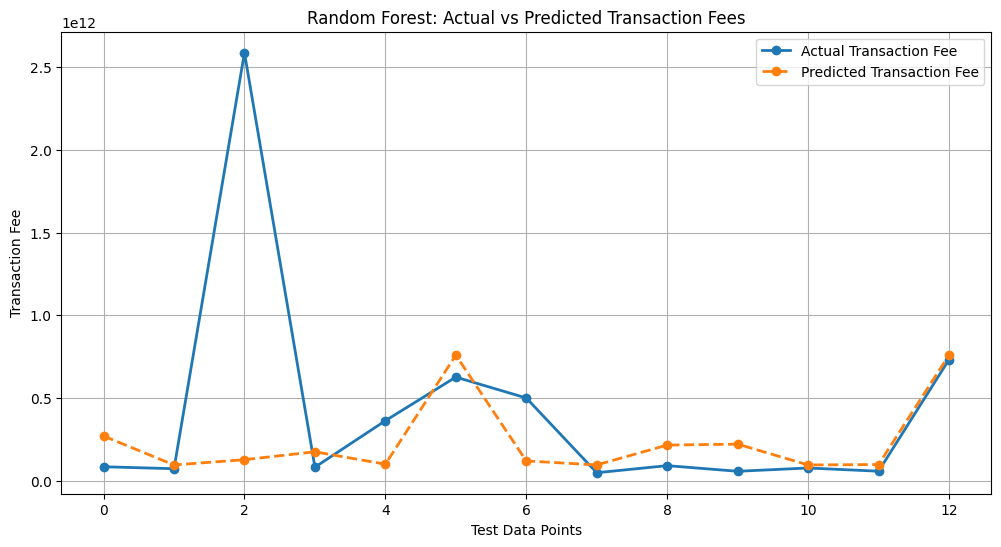

In [ ]:
# Plot Actual vs Predicted Transaction Fees
plt.figure(figsize=(12,6))
# Actual values
plt.plot(
    y_test_fee.values,
    marker='o',
    linewidth=2,
    label='Actual Transaction Fee'
)
# Predicted values
plt.plot(
    rf_fee_pred,
    marker='o',
    linewidth=2,
    linestyle='--',
    label='Predicted Transaction Fee'
)
plt.title('Random Forest: Actual vs Predicted Transaction Fees')
plt.xlabel('Test Data Points')
plt.ylabel('Transaction Fee')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Prepare Transaction Fee data for LSTM

fee_lstm_data = monthly_df['Transaction_Fee'].values.reshape(-1,1)

# Scale data
fee_scaler = MinMaxScaler(feature_range=(0,1))

fee_scaled_data = fee_scaler.fit_transform(fee_lstm_data)

# Display scaled data
print("SCALED TRANSACTION FEE DATA")

print(fee_scaled_data[:5])

SCALED TRANSACTION FEE DATA
[[0.70935181]
 [0.16562567]
 [0.16549687]
 [0.18075537]
 [0.45957896]]


In [ ]:
# Define time step

fee_time_step = 3

# Create sequences
X_fee_lstm = []
y_fee_lstm = []

for i in range(fee_time_step, len(fee_scaled_data)):

    X_fee_lstm.append(
        fee_scaled_data[i-fee_time_step:i, 0]
    )

    y_fee_lstm.append(
        fee_scaled_data[i, 0]
    )

# Convert to numpy arrays
X_fee_lstm = np.array(X_fee_lstm)
y_fee_lstm = np.array(y_fee_lstm)

# Display shapes
print("X_fee_lstm shape:", X_fee_lstm.shape)
print("y_fee_lstm shape:", y_fee_lstm.shape)

X_fee_lstm shape: (56, 3)
y_fee_lstm shape: (56,)


In [ ]:
# Reshape data for LSTM

X_fee_lstm = X_fee_lstm.reshape(
    X_fee_lstm.shape[0],
    X_fee_lstm.shape[1],
    1
)

# Display shape
print("RESHAPED X_fee_lstm SHAPE:", X_fee_lstm.shape)

RESHAPED X_fee_lstm SHAPE: (56, 3, 1)


In [ ]:
# Split data into training and testing sets

fee_train_size = int(len(X_fee_lstm) * 0.8)

X_train_fee_lstm = X_fee_lstm[:fee_train_size]
X_test_fee_lstm = X_fee_lstm[fee_train_size:]

y_train_fee_lstm = y_fee_lstm[:fee_train_size]
y_test_fee_lstm = y_fee_lstm[fee_train_size:]

# Display shapes
print("X_train_fee_lstm shape:", X_train_fee_lstm.shape)
print("X_test_fee_lstm shape:", X_test_fee_lstm.shape)

print("y_train_fee_lstm shape:", y_train_fee_lstm.shape)
print("y_test_fee_lstm shape:", y_test_fee_lstm.shape)

X_train_fee_lstm shape: (44, 3, 1)
X_test_fee_lstm shape: (12, 3, 1)
y_train_fee_lstm shape: (44,)
y_test_fee_lstm shape: (12,)


In [ ]:
# Clear previous session
from tensorflow.keras.backend import clear_session

clear_session()

# Create LSTM model
fee_lstm_model = Sequential()

# Add LSTM layer
fee_lstm_model.add(
    LSTM(
        20,
        return_sequences=False,
        input_shape=(fee_time_step, 1)
    )
)

# Add Dropout layer
fee_lstm_model.add(
    Dropout(0.2)
)

# Output layer
fee_lstm_model.add(
    Dense(1)
)

# Compile model
fee_lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Display model summary
fee_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Transaction Fee LSTM model

fee_history = fee_lstm_model.fit(
    X_train_fee_lstm,
    y_train_fee_lstm,
    epochs=50,
    batch_size=4,
    validation_data=(
        X_test_fee_lstm,
        y_test_fee_lstm
    ),
    verbose=1
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.1664 - val_loss: 0.0012
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1311 - val_loss: 0.0012
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1052 - val_loss: 0.0042
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0820 - val_loss: 0.0096
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0719 - val_loss: 0.0159
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0715 - val_loss: 0.0228
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0662 - val_loss: 0.0248
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0648 - val_loss: 0.0260
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0647 - val_loss: 0.0269
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0573 - val_loss: 0.0244
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0652 - val_loss: 0.0231
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0607 - val_

In [ ]:
# Predict transaction fees using LSTM

fee_lstm_pred = fee_lstm_model.predict(
    X_test_fee_lstm
)

# Reverse scaling
fee_lstm_pred = fee_scaler.inverse_transform(
    fee_lstm_pred
)

# Reverse scaling for actual values
y_test_fee_actual = fee_scaler.inverse_transform(
    y_test_fee_lstm.reshape(-1,1)
)

# Display predictions
print("LSTM TRANSACTION FEE PREDICTIONS")

print(fee_lstm_pred[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
LSTM TRANSACTION FEE PREDICTIONS
[[1.36713839e+11]
 [1.33908046e+11]
 [1.35406191e+11]
 [1.36345502e+11]
 [1.41070107e+11]]


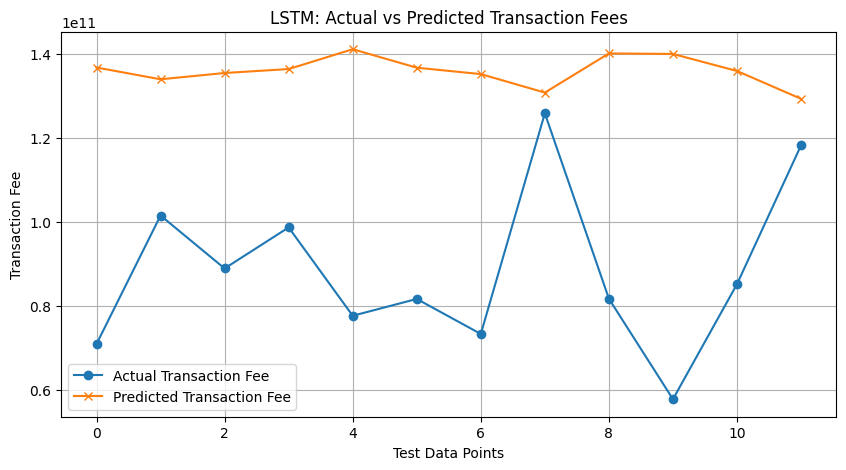

In [ ]:
# Plot Actual vs Predicted Transaction Fees using LSTM

plt.figure(figsize=(10,5))

plt.plot(
    y_test_fee_actual,
    label='Actual Transaction Fee',
    marker='o'
)

plt.plot(
    fee_lstm_pred,
    label='Predicted Transaction Fee',
    marker='x'
)

plt.title(
    'LSTM: Actual vs Predicted Transaction Fees'
)

plt.xlabel('Test Data Points')

plt.ylabel('Transaction Fee')

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Calculate LSTM Transaction Fee Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
# MAE
fee_lstm_mae = mean_absolute_error(
    y_test_fee_actual,
    fee_lstm_pred
)
# RMSE
fee_lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_fee_actual,
        fee_lstm_pred
    )
)
# MAPE
fee_lstm_mape = np.mean(
    np.abs(
        (y_test_fee_actual - fee_lstm_pred)
        / y_test_fee_actual
    )
) * 100
# Display results
print("LSTM TRANSACTION FEE EVALUATION")
print("MAE:", fee_lstm_mae)
print("RMSE:", fee_lstm_rmse)
print("MAPE:", fee_lstm_mape)

LSTM TRANSACTION FEE EVALUATION
MAE: 47543453509.31946
RMSE: 52265269133.68667
MAPE: 61.373767135666526


In [ ]:
# Transaction Fee Model Comparison

transaction_comparison_df = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Random Forest',
        'LSTM'
    ],

    'MAE': [
        fee_mae,
        rf_fee_mae,
        fee_lstm_mae
    ],

    'RMSE': [
        fee_rmse,
        rf_fee_rmse,
        fee_lstm_rmse
    ],

    'MAPE': [
        fee_mape,
        rf_fee_mape,
        fee_lstm_mape
    ],

    'Accuracy (%)': [
        100 - fee_mape,
        100 - rf_fee_mape,
        100 - fee_lstm_mape
    ]

})

print("TRANSACTION FEE MODEL COMPARISON")

display(transaction_comparison_df)

TRANSACTION FEE MODEL COMPARISON


,Model,MAE,RMSE,MAPE,Accuracy (%)
0,Linear Regression,3.111973e+11,6.349978e+11,109.593824,-9.593824
1,Random Forest,3.044628e+11,7.000851e+11,95.333869,4.666131
2,LSTM,4.754345e+10,5.226527e+10,61.373767,38.626233


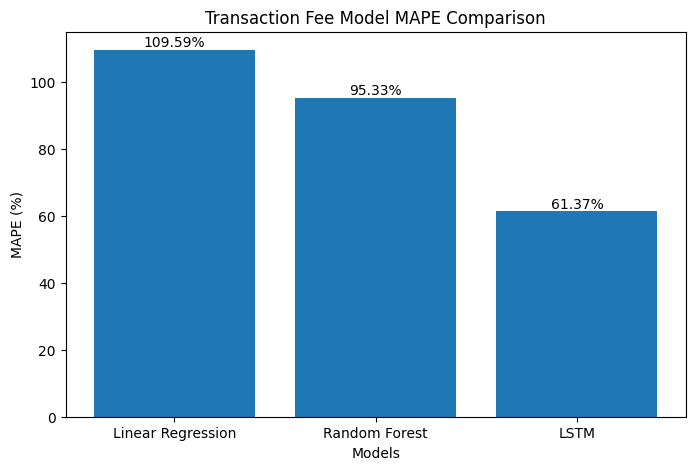

In [ ]:
# Transaction Fee MAPE Comparison Graph

models = [
    'Linear Regression',
    'Random Forest',
    'LSTM'
]

mape_values = [
    fee_mape,
    rf_fee_mape,
    fee_lstm_mape
]

plt.figure(figsize=(8,5))

bars = plt.bar(
    models,
    mape_values
)

# Add MAPE values on bars
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 1,
        f'{yval:.2f}%',
        ha='center'
    )

plt.title(
    'Transaction Fee Model MAPE Comparison'
)

plt.xlabel('Models')

plt.ylabel('MAPE (%)')

plt.show()

In [ ]:
# Create yearly transaction fee dataset

merged_df['Open time'] = pd.to_datetime(merged_df['Open time'])

yearly_fee_df = merged_df.set_index('Open time')[
    ['Transaction_Fee']
].resample('YE').mean()

print("YEARLY TRANSACTION FEE DATASET")

display(yearly_fee_df.head())

YEARLY TRANSACTION FEE DATASET


,Transaction_Fee
Open time,
2018-12-31,3.749799e+11
2019-12-31,1.873257e+11
2020-12-31,3.264484e+11
2021-12-31,4.383755e+11
2022-12-31,8.859648e+10


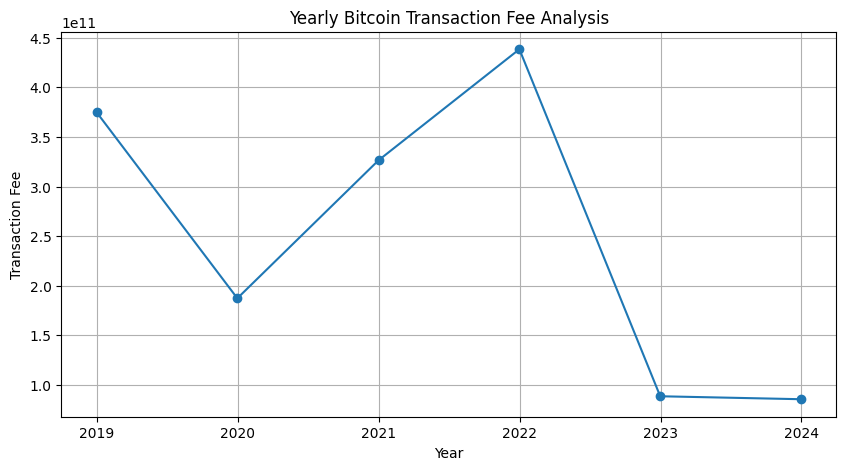

In [ ]:
# Yearly Transaction Fee Analysis Graph

plt.figure(figsize=(10,5))

plt.plot(
    yearly_fee_df.index,
    yearly_fee_df['Transaction_Fee'],
    marker='o'
)

plt.title('Yearly Bitcoin Transaction Fee Analysis')

plt.xlabel('Year')

plt.ylabel('Transaction Fee')

plt.grid(True)

plt.show()

In [ ]:
# Predict future transaction fees using LSTM

future_fee_predictions = []

# Get last sequence
last_sequence = fee_scaled_data[-fee_time_step:]

# Reshape for LSTM
current_sequence = last_sequence.reshape(1, fee_time_step, 1)

# Predict next 12 future values
for i in range(12):

    # Predict next value
    next_pred = fee_lstm_model.predict(current_sequence)

    # Store prediction
    future_fee_predictions.append(next_pred[0, 0])

    # Update sequence
    current_sequence = np.append(
        current_sequence[:, 1:, :],
        [[[next_pred[0, 0]]]],
        axis=1
    )

print("FUTURE TRANSACTION FEE PREDICTIONS GENERATED")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
FUTURE TRANSACTION FEE PREDICTIONS GENERATED


In [ ]:
# Reverse scaling

future_fee_predictions = fee_scaler.inverse_transform(
    np.array(future_fee_predictions).reshape(-1, 1)
)

# Display predictions

print("FUTURE MONTHLY TRANSACTION FEE PREDICTIONS")

print(future_fee_predictions)

FUTURE MONTHLY TRANSACTION FEE PREDICTIONS
[[1.3676072e+11]
 [1.5140841e+11]
 [1.6369073e+11]
 [1.7233206e+11]
 [1.7913368e+11]
 [1.8445343e+11]
 [1.8847133e+11]
 [1.9160343e+11]
 [1.9402939e+11]
 [1.9589816e+11]
 [1.9734956e+11]
 [1.9847391e+11]]


In [ ]:
# Prepare yearly transaction fee data

yearly_fee_data = yearly_fee_df[['Transaction_Fee']]

print("YEARLY TRANSACTION FEE DATA")

display(yearly_fee_data.head())

YEARLY TRANSACTION FEE DATA


,Transaction_Fee
Open time,
2018-12-31,3.749799e+11
2019-12-31,1.873257e+11
2020-12-31,3.264484e+11
2021-12-31,4.383755e+11
2022-12-31,8.859648e+10


In [ ]:
# Scale yearly fee data

yearly_fee_scaler = MinMaxScaler(feature_range=(0,1))

yearly_fee_scaled = yearly_fee_scaler.fit_transform(
    yearly_fee_data
)

print(yearly_fee_scaled[:5])

[[0.82028805]
 [0.28833189]
 [0.68271261]
 [1.        ]
 [0.00845737]]


In [ ]:
# Create yearly sequences

X_yearly_fee = []
y_yearly_fee = []

yearly_fee_time_step = 3

for i in range(
    yearly_fee_time_step,
    len(yearly_fee_scaled)
):

    X_yearly_fee.append(
        yearly_fee_scaled[
            i-yearly_fee_time_step:i,
            0
        ]
    )

    y_yearly_fee.append(
        yearly_fee_scaled[i,0]
    )

X_yearly_fee = np.array(X_yearly_fee)

y_yearly_fee = np.array(y_yearly_fee)

print(X_yearly_fee.shape)

(3, 3)


In [ ]:
# Reshape for LSTM

X_yearly_fee = X_yearly_fee.reshape(
    X_yearly_fee.shape[0],
    X_yearly_fee.shape[1],
    1
)

print(X_yearly_fee.shape)

(3, 3, 1)


In [ ]:
# Build yearly fee LSTM model

yearly_fee_model = Sequential()

yearly_fee_model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_yearly_fee.shape[1],1)
    )
)

yearly_fee_model.add(
    LSTM(50)
)

yearly_fee_model.add(Dense(1))

yearly_fee_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print("YEARLY TRANSACTION FEE LSTM MODEL CREATED")

YEARLY TRANSACTION FEE LSTM MODEL CREATED


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train yearly fee LSTM model

yearly_fee_model.fit(
    X_yearly_fee,
    y_yearly_fee,
    epochs=20,
    batch_size=1,
    verbose=1
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.3318  
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3201
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3045
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2870
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2725
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2633
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2643
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2453
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2431
Epoch 10/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2326
Epoch 11/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2324
Epoch 12/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2333
Epoch 13/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2249
Epoch 14/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2234
Epoch 15/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2225
Epoch 16/20
3/3 ━━━━━━━━━━━━━━━━

In [ ]:
# Predict future yearly transaction fees

future_yearly_fee_predictions = []

yearly_fee_input = yearly_fee_scaled[
    -yearly_fee_time_step:
]

for i in range(5):

    yearly_fee_input_reshaped = yearly_fee_input.reshape(
        1,
        yearly_fee_time_step,
        1
    )

    next_year_fee_pred = yearly_fee_model.predict(
        yearly_fee_input_reshaped,
        verbose=0
    )

    future_yearly_fee_predictions.append(
        next_year_fee_pred[0][0]
    )

    yearly_fee_input = np.append(
        yearly_fee_input[1:],
        next_year_fee_pred,
        axis=0
    )

In [ ]:
# Convert predictions back to original scale

future_yearly_fee_predictions = yearly_fee_scaler.inverse_transform(
    np.array(
        future_yearly_fee_predictions
    ).reshape(-1,1)
)

print("FUTURE YEARLY TRANSACTION FEE PREDICTIONS")

print(future_yearly_fee_predictions)

FUTURE YEARLY TRANSACTION FEE PREDICTIONS
[[1.9334024e+11]
 [1.4989538e+11]
 [1.5781090e+11]
 [1.6886525e+11]
 [1.6418474e+11]]


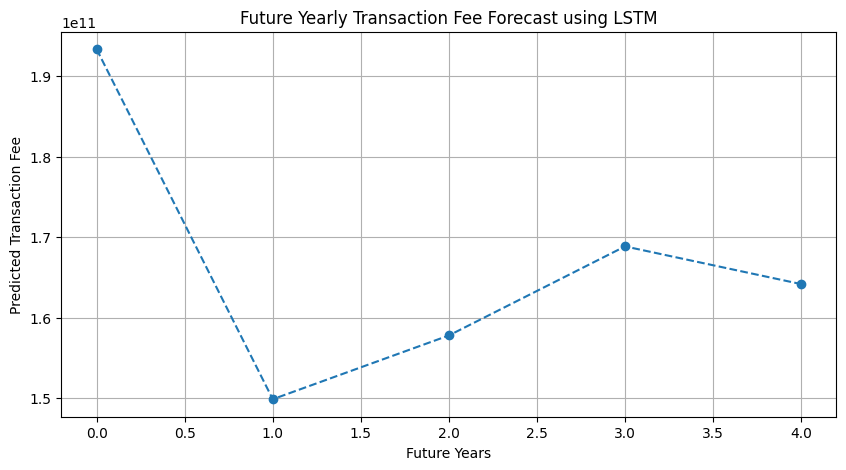

In [ ]:
# Plot future yearly transaction fee forecast

plt.figure(figsize=(10,5))

plt.plot(
    future_yearly_fee_predictions,
    marker='o',
    linestyle='--'
)

plt.title(
    'Future Yearly Transaction Fee Forecast using LSTM'
)

plt.xlabel('Future Years')

plt.ylabel('Predicted Transaction Fee')

plt.grid(True)

plt.show()